# Create LDA for Brandon Sanderson Corpus

## Install Packages

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA, NMF

In [2]:
sns.set_theme(style="white")
pio.renderers.default = "notebook"

#### Set Model Parameters

In [3]:
model_type = 'lda'
colors = 'YlGnBu'

In [4]:
OHCO = ['title', 'chapter_id', 'paragraph_id', 'sent_id', 'token_id']
PARA = OHCO[:3]
CHAP = OHCO[:2]
BOOK = OHCO[:1]
BAG = CHAP

## Get Data

In [5]:
directory_path  = 'C:/Users/mason/Box/Text As Data Final/Output'
TOKENS = pd.read_csv(f"{directory_path}/BrandonSanderson_CORPUS.csv", index_col=0).set_index(OHCO)
TOKENS.head()

token_str term_str  \
title             chapter_id paragraph_id sent_id token_id                      
A Memory of Light 0          0            0       0              The      the   
                                                  1            Wheel    wheel   
                                                  2               of       of   
                                                  3             Time     time   
                                                  4            turns    turns   

                                                            pos pos_group  
title             chapter_id paragraph_id sent_id token_id                 
A Memory of Light 0          0            0       0          DT        DT  
                                                  1         NNP        NN  
                                                  2          IN        IN  
                                                  3         NNP        NN  
                                                  4         NNS        NN

## Convert to a `DOCS` table filtering for Nouns, Verbs, Adjectives, and Adverbs

In [6]:
DOCS = TOKENS[TOKENS.pos.str.match(r'^(NN(?!P)|VB|JJ|RB)')]\
    .groupby(BAG).term_str\
    .apply(lambda x: ' '.join(map(str, x)))\
    .to_frame()\
    .rename(columns={'term_str': 'doc_str'})
DOCS.head()


doc_str
title             chapter_id                                                   
A Memory of Light 0           turns come pass leaving memories become legend...
                  1           pevara did very best pretend was not terrified...
                  2           have indeed patched differences said sitting c...
                  3           was end said sitting wall feel emotions sat st...
                  4           al awoke drew deep breath slipped blankets ten...

## Create Vector Space

In [7]:
from sklearn.feature_extraction import text

my_stop_words = list(text.ENGLISH_STOP_WORDS)
custom_stops = [
    'know', 'asked', 'think', 'people', 'man', 'eyes', 'make', 
    'going', 'want', 'need', 'right', 'got', 'good', 'look', 
    'long', 'away', 'men', 'woman', 'felt', 'did', 'didn', 'don',
    'll', 've', 're', 'nt'
]
my_stop_words.extend(custom_stops)

In [8]:
count_engine = CountVectorizer(max_df = 0.25, min_df=10, stop_words=my_stop_words, ngram_range=(1, 2))
count_model = count_engine.fit_transform(DOCS.doc_str)
TERMS = count_engine.get_feature_names_out()
VOCAB = pd.DataFrame(index=TERMS)
VOCAB.index.name = 'term_str'
DTM = pd.DataFrame(count_model.toarray(), index=DOCS.index, columns=TERMS)
DTM

aback  abandon  abandoned  \
title                          chapter_id                              
A Memory of Light              0               0        0          1   
                               1               0        1          0   
                               2               0        0          0   
                               3               0        0          0   
                               4               0        0          0   
...                                          ...      ...        ...   
Words of Radiance              4               0        0          2   
                               5               0        0          0   
                               6               0        0          0   
                               7               0        0          0   
Yumi and the Nightmare Painter 0               0        0          0   

                                           abandoning  abashed  abilities  \
title                          chapter_id                                   
A Memory of Light              0                    0        0          1   
                               1                    0        0          0   
                               2                    0        0          0   
                               3                    0        0          0   
                               4                    0        0          0   
...                                               ...      ...        ...   
Words of Radiance              4                    0        0          1   
                               5                    0        0          0   
                               6                    0        0          0   
                               7                    0        0          2   
Yumi and the Nightmare Painter 0                    1        0          0   

                                           ability  able escape  able hear  \
title                          chapter_id                                    
A Memory of Light              0                 1            0          0   
                               1                 0            0          0   
                               2                 1            0          0   
                               3                 0            0          0   
                               4                 0            0          0   
...                                            ...          ...        ...   
Words of Radiance              4                 0            0          0   
                               5                 0            0          0   
                               6                 0            0          0   
                               7                 1            0          0   
Yumi and the Nightmare Painter 0                 0            0          0   

                                           able help  ...  youth  youthful  \
title                          chapter_id             ...                    
A Memory of Light              0                   0  ...      2         0   
                               1                   0  ...      0         0   
                               2                   0  ...      0         0   
                               3                   0  ...      0         0   
                               4                   0  ...      1         0   
...                                              ...  ...    ...       ...   
Words of Radiance              4                   0  ...      0         0   
                               5                   0  ...      0         0   
                               6                   0  ...      0         0   
                               7                   0  ...      0         0   
Yumi and the Nightmare Painter 0                   0  ...      0         0   

                                           youths  youyou  zephyr  \
title

## Generate Model

In [9]:
n_topics = 15
max_iter = 100
n_top_terms = 10
TNAMES = [f"T{str(x).zfill(len(str(n_topics)))}" for x in range(n_topics)]

In [10]:
if model_type == 'lda':
    topic_engine = LDA(n_components=n_topics, max_iter=max_iter)
elif model_type == 'nmf':
    topic_engine = NMF(n_components=n_topics, max_iter=max_iter)
topic_model = topic_engine.fit_transform(count_model)

## `THETA` table

In [11]:
THETA = pd.DataFrame(topic_model, index=DOCS.index, columns=TNAMES)
THETA.columns.name = 'topic_id'
THETA.sample(10).T.style.background_gradient(cmap=colors, axis=None)

#### Save Theta Table

In [12]:
THETA.to_csv(f"{directory_path}/BrandonSanderson_THETA.csv")

## PHI

In [13]:
PHI = pd.DataFrame(topic_engine.components_, columns=TERMS, index=TNAMES)
PHI.index.name = 'topic_id'
PHI.columns.name = 'term_str'
PHI.T.sample(10).T.style.background_gradient(cmap=colors, axis=None)

term_str,bites,alive said,alike,special,descended,said quickly,weeks ago,struggle,interesting said,say replied
topic_id,,,,,,,,,,
T00,0.066667,0.066667,4.397358,4.760947,5.052290,6.843844,0.066667,8.017737,1.800648,0.066667
T01,0.066667,4.746057,1.100179,7.954996,0.066667,4.400426,0.066667,0.066667,2.856754,0.066667
T02,10.466483,0.066667,5.808523,11.940498,11.949955,0.066667,0.066667,20.668019,0.066667,0.066667
T03,0.066667,0.066667,0.066667,1.620393,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667
T04,0.066667,0.066667,1.154533,2.333646,0.066667,1.258063,1.139136,0.066667,0.066667,0.066667
T05,7.186875,1.787434,0.066667,58.226001,0.066667,22.154235,11.959871,13.321352,0.066667,7.623958
T06,0.066667,0.066667,1.715440,0.066667,3.318496,0.066667,0.066667,0.066667,1.276578,0.066667
T07,3.328752,0.066667,0.066667,0.066667,2.945924,0.066667,0.066667,3.591576,0.066667,0.066667
T08,0.066667,4.658854,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667


#### Save PHI table

In [14]:
PHI.to_csv(f"{directory_path}/BrandonSanderson_PHI.csv")

## Topics

In [15]:
TOPICS = PHI.stack().groupby('topic_id')\
    .apply(lambda x: ' '.join(x.sort_values(ascending=False).head(n_top_terms).reset_index().term_str))\
    .to_frame('top_terms')
TOPICS

,top_terms
topic_id,
T00,trees horses horse wolves saddle river axe clo...
T01,gun steel tunnel mobile team hole enforcement ...
T02,creature soldier cursed pool hallway wound spe...
T03,skaa mists pewter metals ash tin crew atium no...
T04,emperor stamp seal soul storm book parshmen st...
T05,lord lady throne children duke lord said agree...
T06,planet ships glowing ship cycle knight energy ...
T07,priests priest sule palace elantrian gods chap...
T08,ship spores captain tress deck crew sailors vi...


## Topics by Doc Weight

#### Mean

In [16]:
TOPICS['doc_weight_mean'] = THETA.mean()
TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
TOPICS.sort_values('doc_weight_mean', ascending=False).head(5).style.background_gradient(cmap='YlGnBu', axis=0)

C:\Users\mason\AppData\Local\Temp\ipykernel_5964\1845078788.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
C:\Users\mason\AppData\Local\Temp\ipykernel_5964\1845078788.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()


,top_terms,doc_weight_mean,term_freq
topic_id,,,
T05,lord lady throne children duke lord said agreed cup brother conversation,0.213824,0.220954
T02,creature soldier cursed pool hallway wound spear bodies rock vines,0.160320,0.164732
T09,gun train governor kandra bubble speed rusts car waxillium mists,0.127099,0.111400
T14,spren tower storms shallan fused sphere spheres storm fabrial humans,0.078971,0.075193
T11,camp gateway bloody battlefield tent horse weave armies fought forces,0.066854,0.102782


#### Sum

In [17]:
TOPICS['doc_weight_sum'] = THETA.sum()
TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
TOPICS.sort_values('doc_weight_sum', ascending=False).style.background_gradient(cmap='YlGnBu', axis=0)

C:\Users\mason\AppData\Local\Temp\ipykernel_5964\2717084757.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
C:\Users\mason\AppData\Local\Temp\ipykernel_5964\2717084757.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()


,top_terms,doc_weight_mean,term_freq,doc_weight_sum
topic_id,,,,
T05,lord lady throne children duke lord said agreed cup brother conversation,0.213824,0.220954,138.985610
T02,creature soldier cursed pool hallway wound spear bodies rock vines,0.160320,0.164732,104.207901
T09,gun train governor kandra bubble speed rusts car waxillium mists,0.127099,0.111400,82.614281
T14,spren tower storms shallan fused sphere spheres storm fabrial humans,0.078971,0.075193,51.330874
T11,camp gateway bloody battlefield tent horse weave armies fought forces,0.066854,0.102782,43.455070
T06,planet ships glowing ship cycle knight energy heat soul gun,0.054071,0.043741,35.145876
T07,priests priest sule palace elantrian gods chapel gyorn god princess,0.053605,0.045408,34.842947
T08,ship spores captain tress deck crew sailors vines dragon sea,0.049690,0.028562,32.298774
T10,cloak village inn gleeman al innkeeper road cart horses crowd,0.048250,0.067580,31.362511


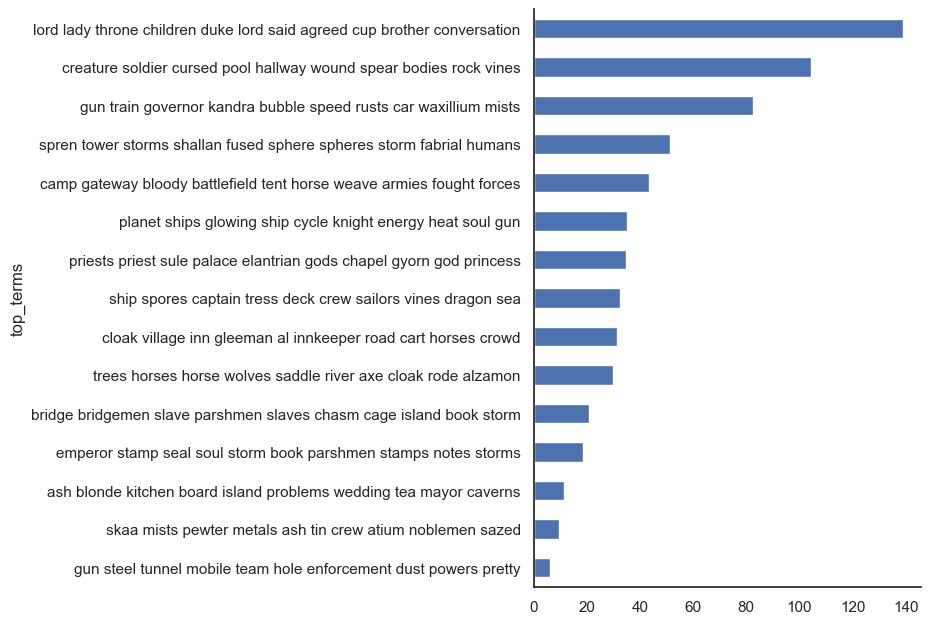

In [18]:
TOPICS.sort_values('doc_weight_sum', ascending=True).plot.barh(y='doc_weight_sum', x='top_terms', figsize=(5, n_topics/2), legend=False)
sns.despine()
plt.show()

## Topics by Book

In [19]:
TOPIC_BOOK = THETA.groupby('title').mean()
TOPIC_BOOK.T.style.background_gradient(axis=0, cmap="YlGnBu")

title,A Memory of Light,Arcanum Unbounded,Elantris,Isles of the Emberdark,Oathbringer,Rhythm of War,Shadows of Self,Steelheart,The Aether of Night,The Alloy of Law,The Bands of Mourning,The Final Empire,The Hero of Ages,The Lost Metal,The Sunlit Man,The Way of Kings,The Well of Ascension,The Wheel of Time,Towers of Midnight,Tress of the Emerald Sea,Warbreaker,Wind and Truth,Words of Radiance,Yumi and the Nightmare Painter
topic_id,,,,,,,,,,,,,,,,,,,,,,,,
T00,0.043968,0.004749,0.006094,0.015810,0.006801,0.001812,0.015955,0.002683,0.006544,0.000405,0.003712,0.012534,0.000315,0.000779,0.002032,0.015886,0.000632,0.451211,0.042273,0.005243,0.007806,0.004611,0.012965,0.000392
T01,0.005746,0.000411,0.000701,0.003384,0.000838,0.000072,0.021900,0.353449,0.001759,0.000405,0.007588,0.006157,0.004817,0.007550,0.002306,0.012524,0.000632,0.000086,0.000087,0.012529,0.014525,0.000148,0.000223,0.000392
T02,0.145069,0.162831,0.232974,0.550967,0.247569,0.188753,0.156893,0.097950,0.264353,0.080019,0.140069,0.120956,0.206917,0.058845,0.128631,0.204332,0.119600,0.049753,0.103237,0.073708,0.214587,0.231745,0.343180,0.000392
T03,0.000739,0.002347,0.001411,0.000268,0.001589,0.000072,0.004739,0.000032,0.000124,0.026831,0.000960,0.343564,0.168332,0.006732,0.004361,0.009837,0.284474,0.000121,0.000655,0.000230,0.005320,0.000148,0.000223,0.000392
T04,0.003190,0.304564,0.001307,0.001919,0.097922,0.008432,0.010668,0.000032,0.035189,0.002057,0.000198,0.046238,0.000315,0.027719,0.022747,0.057962,0.025654,0.000086,0.025201,0.000230,0.033983,0.081758,0.024901,0.733925
T05,0.183071,0.276718,0.457337,0.109410,0.106614,0.180822,0.160910,0.120068,0.614121,0.170202,0.183178,0.215827,0.307812,0.176818,0.122278,0.116708,0.336302,0.034063,0.375856,0.202142,0.160897,0.174065,0.130826,0.000392
T06,0.004943,0.098263,0.006872,0.042386,0.002350,0.003335,0.007515,0.326899,0.001188,0.065022,0.009834,0.010908,0.005688,0.100771,0.555728,0.009837,0.000632,0.000465,0.000918,0.028517,0.016496,0.000148,0.001553,0.260977
T07,0.002667,0.024964,0.236368,0.013877,0.008291,0.002286,0.012696,0.003019,0.004694,0.000405,0.002037,0.019557,0.015393,0.003163,0.000172,0.013303,0.018497,0.000086,0.010130,0.001674,0.441906,0.000148,0.000223,0.000392
T08,0.000890,0.000411,0.003355,0.029303,0.000629,0.004670,0.004328,0.000032,0.000684,0.004304,0.017256,0.006609,0.057549,0.010011,0.014869,0.014346,0.000632,0.003829,0.000309,0.419620,0.004815,0.004726,0.037123,0.000392
